# RNN, LSTM, and GRU for Sequential Data

**Unit:** Unit 4: Neural Networks Fundamentals

Every network we have trained so far looks at one *snapshot* — an image, a row of features — and forgets it immediately. But many real signals are *sequences* where order carries the meaning: sensor readings, stock prices, words in a sentence. To predict what comes next, a network needs **memory** of what came before. Recurrent networks add exactly that: a hidden state passed from one time step to the next. In `02_cnn_rnn_architectures.ipynb` we only printed these architectures' summaries; here we actually train the three classic recurrent cells — SimpleRNN, LSTM, and GRU — on the *same* forecasting task with the *same* hidden size and training budget, and let the measured validation error tell us which memory design works best on this task.

## 📚 Learning Objectives

By completing this notebook, you will:
- Turn a continuous signal into (window -> next value) training sequences
- Explain intuitively what gates add: SimpleRNN vs. LSTM vs. GRU
- Train all three cells under an identical budget and compare validation MSE from actual results
- Read a predictions-vs-truth plot to judge forecast quality beyond a single number

## 🔗 Prerequisites

- ✅ Basic Keras models (`01_simple_perceptron.ipynb`)
- ✅ CNN/RNN architecture vocabulary (`02_cnn_rnn_architectures.ipynb`)

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- A synthetic signal generated in-notebook (sum of two sine waves + noise) — no downloads
- Sliding windows of **40 past values** used to predict the **next value**

**Outputs:** What you'll see when you run the cells

- Printed dataset sizes and per-model parameter counts
- A table of final validation MSE for SimpleRNN, LSTM, and GRU
- One plot overlaying the three models' predictions against the true signal

---

Signal length:     1200 points
Training windows:  928  (each is 40 steps -> predict step 41)
Validation windows:  232  (held-out later portion of the signal)


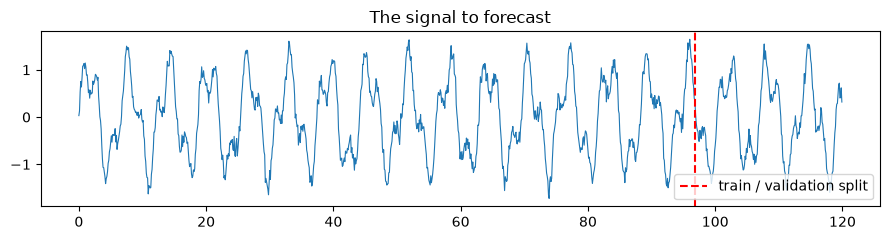

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

tf.get_logger().setLevel("ERROR")  # hide harmless tf.function retracing notices
keras.utils.set_random_seed(42)  # reproducible runs

# A toy signal: two overlapping sine waves plus a little noise.
# Not perfectly periodic at first glance -- the model must learn the pattern, not memorize it.
t = np.arange(0, 120, 0.1)
rng = np.random.default_rng(42)
series = np.sin(t) + 0.5 * np.sin(2.7 * t) + 0.1 * rng.normal(size=len(t))

# Sliding windows: 40 past values -> predict the next one
WINDOW = 40
X = np.array([series[i : i + WINDOW] for i in range(len(series) - WINDOW)])[..., None].astype("float32")
y = np.array([series[i + WINDOW] for i in range(len(series) - WINDOW)]).astype("float32")

# Time-ordered split: train on the first 80%, validate on the last 20% (the "future")
n_train = int(0.8 * len(X))
X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:], y[n_train:]

print(f"Signal length:     {len(series)} points")
print(f"Training windows:  {len(X_train)}  (each is {WINDOW} steps -> predict step {WINDOW + 1})")
print(f"Validation windows:{len(X_val):5d}  (held-out later portion of the signal)")

plt.figure(figsize=(9, 2.5))
plt.plot(t, series, lw=0.8)
plt.axvline(t[n_train + WINDOW], color="red", ls="--", label="train / validation split")
plt.title("The signal to forecast")
plt.legend()
plt.tight_layout()
plt.show()

## Three ways to remember: SimpleRNN, LSTM, GRU

All three cells read the window one step at a time, carrying a hidden state forward. They differ in *how* that memory is managed:

- **SimpleRNN** — one memory vector, **overwritten at every step** (`new state = f(input, old
  state)`). There is no mechanism to protect old information, so what happened 40 steps ago has
  been rewritten 40 times and mostly fades away (the *vanishing gradient* problem from the
  lectures).
- **LSTM** — adds a separate *cell state* that flows through time like a conveyor belt, plus
  three **gates** (small learned valves outputting 0-1): the **forget gate** decides what to
  erase from the belt, the **input gate** decides what new information to write onto it, and the
  **output gate** decides how much of the belt to reveal at this step. Because information can
  ride the belt untouched, long-range patterns survive.
- **GRU** — the economy version of the LSTM: two gates instead of three (an **update gate**
  merging forget+input into one "keep old vs. take new" dial, and a **reset gate** controlling
  how much history feeds the new candidate). Fewer parameters, often similar quality.

**The experiment:** identical data, identical hidden size (32 units), identical epochs, optimizer, and batch size — the *only* change is the recurrent cell. Note honestly: same hidden width does **not** mean same parameter count, because the gates are extra weights; the printed counts below show it.

In [2]:
def build_model(cell_class):
    """Same architecture for all three: one recurrent layer (32 units) + linear output."""
    model = keras.Sequential(
        [keras.Input(shape=(WINDOW, 1)), cell_class(32), keras.layers.Dense(1)]
    )
    model.compile(optimizer="adam", loss="mse")
    return model

cells_to_test = [
    ("SimpleRNN", keras.layers.SimpleRNN),
    ("LSTM", keras.layers.LSTM),
    ("GRU", keras.layers.GRU),
]

EPOCHS = 15
results = {}
for name, cell_class in cells_to_test:
    keras.utils.set_random_seed(42)  # identical init/shuffling conditions for each model
    model = build_model(cell_class)
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=EPOCHS, batch_size=32, verbose=0)
    val_mse = model.evaluate(X_val, y_val, verbose=0)
    results[name] = {"model": model, "params": model.count_params(), "val_mse": val_mse}
    print(f"{name:9s} trained: {model.count_params():5,} parameters, "
          f"final val MSE = {val_mse:.4f}  ({EPOCHS} epochs)")

SimpleRNN trained: 1,121 parameters, final val MSE = 0.0133  (15 epochs)


LSTM      trained: 4,385 parameters, final val MSE = 0.0125  (15 epochs)


GRU       trained: 3,393 parameters, final val MSE = 0.0196  (15 epochs)


=== Final validation MSE (same data, 32 units, 15 epochs each) ===
model        params   val MSE
LSTM          4,385    0.0125
SimpleRNN     1,121    0.0133
GRU           3,393    0.0196

Best on this run: LSTM (val MSE 0.0125)


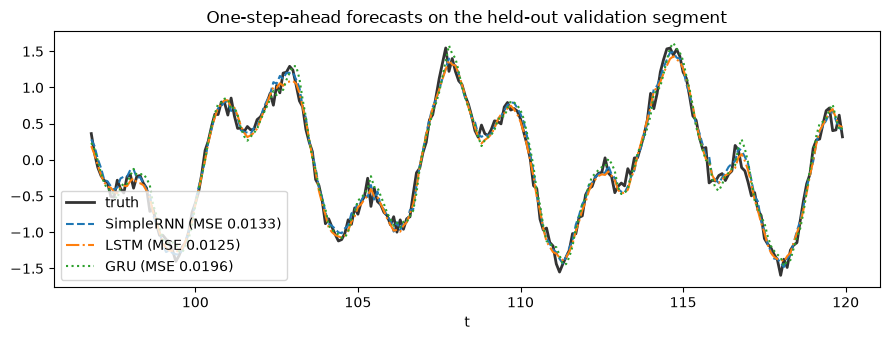

In [3]:
# One table of final validation MSE, ranked best (lowest) first
print("=== Final validation MSE (same data, 32 units, 15 epochs each) ===")
print(f"{'model':<10} {'params':>8} {'val MSE':>9}")
ranked = sorted(results.items(), key=lambda kv: kv[1]["val_mse"])
for name, r in ranked:
    print(f"{name:<10} {r['params']:>8,} {r['val_mse']:>9.4f}")
print(f"\nBest on this run: {ranked[0][0]} (val MSE {ranked[0][1]['val_mse']:.4f})")

# One plot: the three models' one-step-ahead predictions vs. the true signal
preds = {name: r["model"].predict(X_val, verbose=0).ravel() for name, r in results.items()}
t_val = t[n_train + WINDOW :]

plt.figure(figsize=(9, 3.5))
plt.plot(t_val, y_val, "k-", lw=2, label="truth", alpha=0.8)
for (name, p), style in zip(preds.items(), ["--", "-.", ":"]):
    plt.plot(t_val, p, style, lw=1.5, label=f"{name} (MSE {results[name]['val_mse']:.4f})")
plt.title("One-step-ahead forecasts on the held-out validation segment")
plt.xlabel("t")
plt.legend()
plt.tight_layout()
plt.show()

### What the numbers say

**On this run the LSTM won**, with a final validation MSE of **0.0125**, followed closely by SimpleRNN (**0.0133**), with GRU last (**0.0196**). Three honest readings of that table:

1. **The margin is small — and that is expected here.** Every pattern the models need fits
   inside the 40-step input window of a clean, repeating signal. That is exactly the regime a
   gate-free SimpleRNN can still handle, which is why it stays within striking distance of the
   LSTM at a quarter of the parameters (1,121 vs. 4,385). Gates earn their cost on *longer*
   sequences with *long-range* dependencies — remembering something from hundreds of steps ago,
   as in text — where a SimpleRNN's constantly overwritten memory collapses.
2. **We are near the noise floor.** The signal carries added noise with standard deviation 0.1,
   i.e. variance 0.01 — no one-step forecaster can average below that MSE. All three models sit
   close to it, and the plot shows all three tracking the truth well.
3. **Toy-task rankings are fragile.** With a different seed or epoch budget the ordering (
   especially GRU's last place, at odds with its usual reputation) can shuffle. The durable
   lesson is not "LSTM is always best" — it is the *mechanism*: gated cells can protect
   information across many steps, while a SimpleRNN rewrites its entire memory at every step.